# AB Aur: fitting θ_off and the IP from the data

The companion to `compare_ab_aur.ipynb`. That one **pins** both choices —
`fast_axis_method = "fixed"` at the commissioning notebook's θ_off, and
`ip_method = None` — because it compares against a fixed reference and fitting
would make that a moving target.

This one **fits both**, and shows the working: the scan curve behind the
offset, the solver's convergence, the per-cycle spread of the leakage, and
what each step does to U_phi.

**Everything here rests on one assumption: the source is azimuthally
polarized.** A disk in scattered light puts all its signal in Q_phi and leaves
U_phi as noise, so "minimise U_phi" is a meaningful objective. On a target
where that is the hypothesis under test, every method below returns a
confident, meaningless number. AB Aur is a disk, so it is fair game.

## 0. Config and reduction

The same steps as `compare_ab_aur.ipynb`, compressed — that notebook explains
them. Only the fitting differs, and that starts at section 3.

In [1]:
import glob, logging, os, sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

from instruments.nirc2 import NIRC2PolarimetryData
from polarimetry import (build_stokes_cubes, butterfly_phase,
                         combine_at_offset, fit_fast_axis_butterfly,
                         fit_ip_uphi, fit_ip_uphi_all, mean_ip,
                         median_stokes_cube, prepare_cycles, radial_stokes,
                         scan_fast_axis_offset_butterfly)
from reduction import (fit_beam_geometry, make_master_darks,
                       make_master_flats, make_master_masks, reduce_frame)
from reduction.config import ReductionConfig
from utils import crop, frame_number, load_frames

logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(message)s")

cfg = ReductionConfig(
    observations_root="/home/shared/exoserver/NIRC2_Pol/20251207",
    date="2025-12-07",
    target="AB_Aur",
    select_frame_range=[[857, 900], [915, 930], [932, 963]],
    background_method="mean_box",
    background_box=[25, 350, 50, 400],
    register_method="min",           # AB Aur's core is saturated
    fast_axis_method="butterfly",    # fitted here, not pinned
    ip_method="fit_uphi_all",        # fitted here too
    ip_mask_radius=22.0,
)

NOTEBOOK_DIR = os.path.expanduser("~/AB-Aur")
RAW_RANGE = (857, 993)      # science + the sky flats and darks between them
FIT_RADII = (25, 150)       # the butterfly annulus: spans the disk
CROP = 400
OUT_DIR = "compare_ab_aur_output"

instrument = cfg.configure(NIRC2PolarimetryData())

In [2]:
lo, hi = RAW_RANGE
raw = [f for f in sorted(glob.glob(os.path.join(cfg.observations_root, "n*.fits")))
       if lo <= frame_number(f) <= hi]
sorted_files = instrument.sort_frames(raw)

master_darks, dark_masks = make_master_darks(
    load_frames(sorted_files["darks"]), instrument=instrument)
master_flats, flat_masks = make_master_flats(
    load_frames(sorted_files["flats_dome"]),
    load_frames(sorted_files["flats_sky"]),
    master_darks, instrument=instrument)
master_masks = make_master_masks(dark_masks, flat_masks)

wanted = lambda p: any(a <= frame_number(p) <= b
                       for a, b in cfg.select_frame_range)
bad_pixel_mask = instrument.bad_pixel_mask()
frames = [reduce_frame(f, master_flats, master_darks, None, master_masks,
                       bad_pixel_mask=bad_pixel_mask,
                       required_flat_types=instrument.required_flat_types,
                       default_required_flat_type=instrument.default_required_flat_type,
                       gain=instrument.gain(f),
                       saturation_limit=instrument.saturation_limit(f))
          for f in load_frames([p for p in sorted_files["sci"] if wanted(p)])]

instrument.top_row_start, instrument.beam_x_offset = fit_beam_geometry(
    instrument, frames)
cycles = instrument.match_modulator_cycles(frames)
print(f"{len(frames)} frames, {len(cycles)} cycles, "
      f"geometry {instrument.top_row_start}/{instrument.beam_x_offset}")

WARNING Lp flats cover the cycle unevenly (0deg x3, 22.5deg x3, 45deg x3, 67.5deg x4), so 3 balanced cycle(s) are kept and 1 surplus frame(s) set aside: n0913.fits. These are sound frames -- they are dropped only because an angle observed more often than the others weights the cycle average toward it, and the flat source's own polarization stops cancelling.


WARNING Measured beam_x_offset = 12.63 sits between pixels, so rounding either way leaves about half a pixel of beam misalignment. Compare both by reducing with each and seeing which gives less U_phi.


92 frames, 23 cycles, geometry 505/13


## 1. Reduce each cycle once, with θ_off still free

The trick that makes all of this cheap: θ_off enters the rotation only as
`+4·θ_off` (SPIE Eq. 3), so a cycle can be double-differenced **once** and then
re-rotated to any trial offset. `prepare_cycles` does the expensive part —
beam splitting, background, registration, double differencing — and
`combine_at_offset` recombines at a trial offset for the price of a rotation.

Without this, every point on the scan below would need a full reduction.

In [3]:
prepared = prepare_cycles(instrument, cycles,
                          register_method=cfg.register_method)
print(f"{len(prepared)} prepared cycles; each holds instrument-frame Q, U, I")
print("and the rotation it would get at theta_off = 0:")
for p in prepared[:3]:
    print(f"   rot_at_zero = {p.rot_at_zero:+8.3f} deg")

23 prepared cycles; each holds instrument-frame Q, U, I
and the rotation it would get at theta_off = 0:
   rot_at_zero = -466.703 deg
   rot_at_zero = -462.997 deg
   rot_at_zero = -459.257 deg


## 2. The scan: what the objective actually looks like

`scan_fast_axis_offset_butterfly` scores a grid of trial offsets. **This is the
diagnostic, not the solver** — the solver returns one number, and the only way
to know whether that number sits at a real, isolated minimum is to look at the
curve behind it.

Two things to check on it. Is there a single clear minimum, or a flat bottom
the fit could wander in? And is it a smooth cosine, as the model says it should
be — θ_off enters as `4·θ_off`, so the curve repeats every 90°.

grid minimum at -13.0 deg


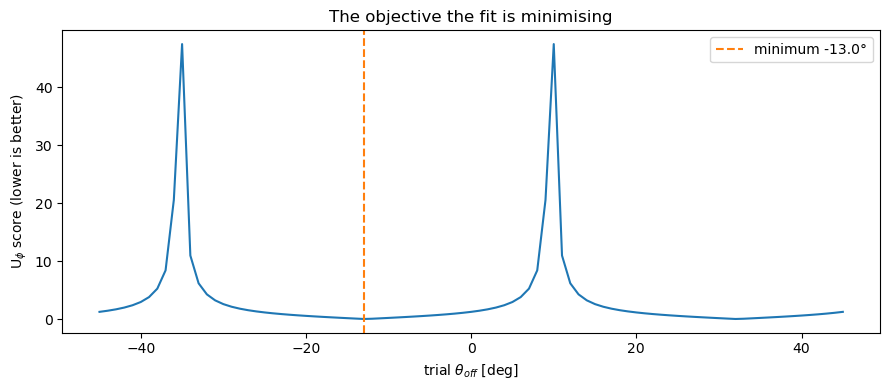

In [4]:
offsets = np.arange(-45, 45.1, 1.0)
_, scores = scan_fast_axis_offset_butterfly(
    prepared, offsets=offsets, r_inner=FIT_RADII[0], r_outer=FIT_RADII[1])

best = float(offsets[np.argmin(scores)])
print(f"grid minimum at {best:+.1f} deg")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(offsets, scores, lw=1.5)
ax.axvline(best, color="C1", ls="--", label=f"minimum {best:+.1f}°")
ax.set_xlabel(r"trial $\theta_{off}$ [deg]")
ax.set_ylabel("U$_\\phi$ score (lower is better)")
ax.set_title("The objective the fit is minimising")
ax.legend()
fig.tight_layout()

### The degeneracy worth knowing about

The curve repeats every 90°, and within one period there is a second feature:
θ_off and θ_off + 45° both flatten U_phi, because a 45° rotation of the
polarization frame swaps Q_phi and U_phi — turning the disk signal into the
null channel and vice versa. Minimising U_phi alone cannot tell them apart.

`butterfly_phase` can: it measures which way the four-lobe pattern is turned,
so it pins the offset **mod 90°** rather than mod 45°. That is why the solver
uses it rather than a plain minimiser.

In [5]:
for trial in (best, best + 45.0):
    Q, U, _ = combine_at_offset(prepared, trial)
    qp, up = radial_stokes(Q, U)
    ny, nx = Q.shape
    yy, xx = np.mgrid[:ny, :nx]
    r = np.hypot(yy - (ny - 1) / 2, xx - (nx - 1) / 2)
    ann = (r > FIT_RADII[0]) & (r < FIT_RADII[1])
    print(f"  theta_off {trial:+6.1f}:  mean Q_phi {np.nanmean(qp[ann]):+9.3f}"
          f"   std U_phi {np.nanstd(up[ann]):8.3f}")
print()
print("Same U_phi, opposite Q_phi: that is the 45 deg degeneracy.")

  theta_off  -13.0:  mean Q_phi   +64.715   std U_phi   17.226


  theta_off  +32.0:  mean Q_phi   -64.715   std U_phi   17.226

Same U_phi, opposite Q_phi: that is the 45 deg degeneracy.


## 3. The solver

`fit_fast_axis_butterfly` iterates one closed-form step: rotate to sky at the
current offset, measure how far the butterfly is still turned, correct by
`delta / 4`, repeat. `delta_history` is that correction at each step, and it
should collapse toward zero.

It fits the **offset only**. Passing `ip=` removes a leakage you already have
before fitting; leaving it `None`, as here, fits with the leakage still in —
which biases the offset, because the two are degenerate. Nothing in the
package produces an assumption-free leakage to pass, so this is the honest
starting point, and section 4 measures how much it cost.

In [6]:
result = fit_fast_axis_butterfly(
    instrument, cycles, ip=None, prepared=prepared,
    r_inner=FIT_RADII[0], r_outer=FIT_RADII[1])

print(result.describe())
print()
print("convergence (the correction applied at each step):")
for i, d in enumerate(result.delta_history, 1):
    print(f"   step {i}: delta = {d:+9.5f} deg  ->  theta_off correction "
          f"{d / 4:+8.5f}")
theta_off = result.theta_off

theta_off=-12.8020 deg (on-sky butterfly, 2 iter, converged=True)

convergence (the correction applied at each step):
   step 1: delta = -51.20771 deg  ->  theta_off correction -12.80193
   step 2: delta =  -0.00013 deg  ->  theta_off correction -0.00003


## 4. The leakage

Now the IP, with θ_off fixed at what section 3 found. Both routes minimise the
same U_phi scatter; they differ in whether one pair is fitted across every
cycle at once, or one pair per cycle and then averaged.

`fit_uphi_per_cycle` also gives an error bar for free — the scatter across
cycles — which the all-cycle fit cannot.

In [7]:
ip_all = fit_ip_uphi_all(instrument, cycles, theta_off,
                         mask_radius=cfg.ip_mask_radius, crop_size=CROP,
                         register_method=cfg.register_method)
print("all cycles at once :", ip_all.describe())

per_cycle = [fit_ip_uphi(instrument, c, theta_off,
                         mask_radius=cfg.ip_mask_radius, crop_size=CROP,
                         register_method=cfg.register_method)
             for c in cycles]
ip_mean = mean_ip(per_cycle)
print("per cycle, averaged :", ip_mean.describe())
print("   error bar: ipq +-%.4f, ipu +-%.4f"
      % (ip_mean.diagnostics["ipq_err"], ip_mean.diagnostics["ipu_err"]))

all cycles at once : ipq=-0.00513 ipu=-0.00512 (0.725% at 112.5deg) method=uphi_min scope=sequence_joint


per cycle, averaged : ipq=-0.00485 ipu=-0.00550 (0.734% at 114.3deg) method=uphi_min scope=sequence_mean
   error bar: ipq +-0.0006, ipu +-0.0009


A cycle far off the others is worth looking at rather than averaging in:
   cycle 16: ipq -0.0129 against -0.0051 for the whole sequence


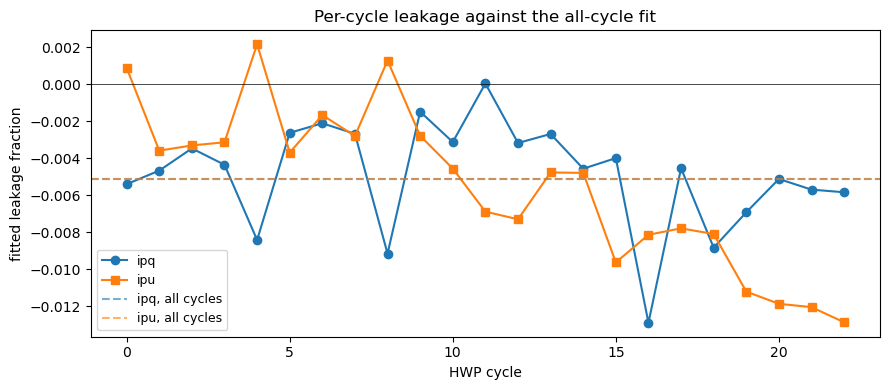

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([p.ipq for p in per_cycle], "o-", label="ipq")
ax.plot([p.ipu for p in per_cycle], "s-", label="ipu")
ax.axhline(ip_all.ipq, color="C0", ls="--", alpha=0.6, label="ipq, all cycles")
ax.axhline(ip_all.ipu, color="C1", ls="--", alpha=0.6, label="ipu, all cycles")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("HWP cycle"); ax.set_ylabel("fitted leakage fraction")
ax.set_title("Per-cycle leakage against the all-cycle fit")
ax.legend(fontsize=9)
fig.tight_layout()

print("A cycle far off the others is worth looking at rather than averaging in:")
worst = max(range(len(per_cycle)), key=lambda i: abs(per_cycle[i].ipq - ip_all.ipq))
print(f"   cycle {worst}: ipq {per_cycle[worst].ipq:+.4f} against "
      f"{ip_all.ipq:+.4f} for the whole sequence")

## 5. Did any of it help?

The honest test. U_phi is the null channel, so a correction that is doing
something real should lower it **without** eating Q_phi — if both fall
together, the correction is removing signal rather than leakage.

In [9]:
def score(ip, label):
    med = median_stokes_cube(build_stokes_cubes(
        instrument, cycles, fast_axis_offset=theta_off,
        register_method=cfg.register_method, ip=ip))
    ny, nx = med[1].shape
    st = ((ny - 1) / 2, (nx - 1) / 2)
    Q, sr, sc = crop(med[1], (CROP, CROP), center=st)
    U, _, _ = crop(med[2], (CROP, CROP), center=st)
    star = (st[0] - sr, st[1] - sc)
    qp, up = radial_stokes(Q, U, center=star)
    yy, xx = np.mgrid[:CROP, :CROP]
    r = np.hypot(yy - star[0], xx - star[1])
    ann = (r > 22) & (r < 150)
    print("  %-26s U_phi std %8.4f    Q_phi mean %9.3f"
          % (label, float(np.nanstd(up[ann])), float(np.nanmean(qp[ann]))))
    return med, qp, up, ann, star

print(f"at theta_off = {theta_off:+.4f}:")
med_none, qphi, uphi, ann, star = score(None, "no IP correction")
med_all, qphi_a, uphi_a, _, _ = score(ip_all, "fit_uphi_all")
med_pc, _, _, _, _ = score(per_cycle, "fit_uphi_per_cycle")

at theta_off = -12.8020:


/home/blewis/NIRC2Pol-DPP/examples/../polarimetry/stokes.py:413: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian(np.asarray(stokes_cubes), axis=0)


  no IP correction           U_phi std  12.5323    Q_phi mean    66.053


  fit_uphi_all               U_phi std  11.8879    Q_phi mean    65.687


  fit_uphi_per_cycle         U_phi std  11.1720    Q_phi mean    65.773


## 6. Against the commissioning notebook

The same comparison `compare_ab_aur.ipynb` makes, but at the **fitted** offset
rather than the notebook's own, so the two numbers can be read side by side.

In [10]:
from utils.imutils import translate

nb_qphi = fits.getdata(os.path.join(NOTEBOOK_DIR, "qphi_median.fits"))
nb_uphi = fits.getdata(os.path.join(NOTEBOOK_DIR, "uphi_median.fits"))
nb_c = (203.0, 197.0)
dy, dx = star[0] - nb_c[0], star[1] - nb_c[1]
nb_qphi_al = translate(np.nan_to_num(nb_qphi), dy, dx)
nb_uphi_al = translate(np.nan_to_num(nb_uphi), dy, dx)

sel = ann & np.isfinite(qphi_a) & np.isfinite(nb_qphi_al) & (nb_qphi_al != 0)
a, b = qphi_a[sel], nb_qphi_al[sel]
scale = float(np.nansum(a * b) / np.nansum(a * a))
corr = float(np.corrcoef(a, b)[0, 1])

print(f"theta_off        {theta_off:+.4f} (fitted; the notebook used -8.0278)")
print(f"correlation      {corr:.4f}")
print(f"fitted scale     {scale:.4g}")
print(f"U_phi std ratio  "
      f"{np.nanstd(scale * uphi_a[sel]) / np.nanstd(nb_uphi_al[sel]):.3f}"
      f"   (rescaled; <1 means ours is cleaner)")

theta_off        -12.8020 (fitted; the notebook used -8.0278)
correlation      0.9691
fitted scale     0.844
U_phi std ratio  0.432   (rescaled; <1 means ours is cleaner)


## 7. What it looks like

Before and after, in the null channel where any change shows up most clearly.

wrote products to compare_ab_aur_output


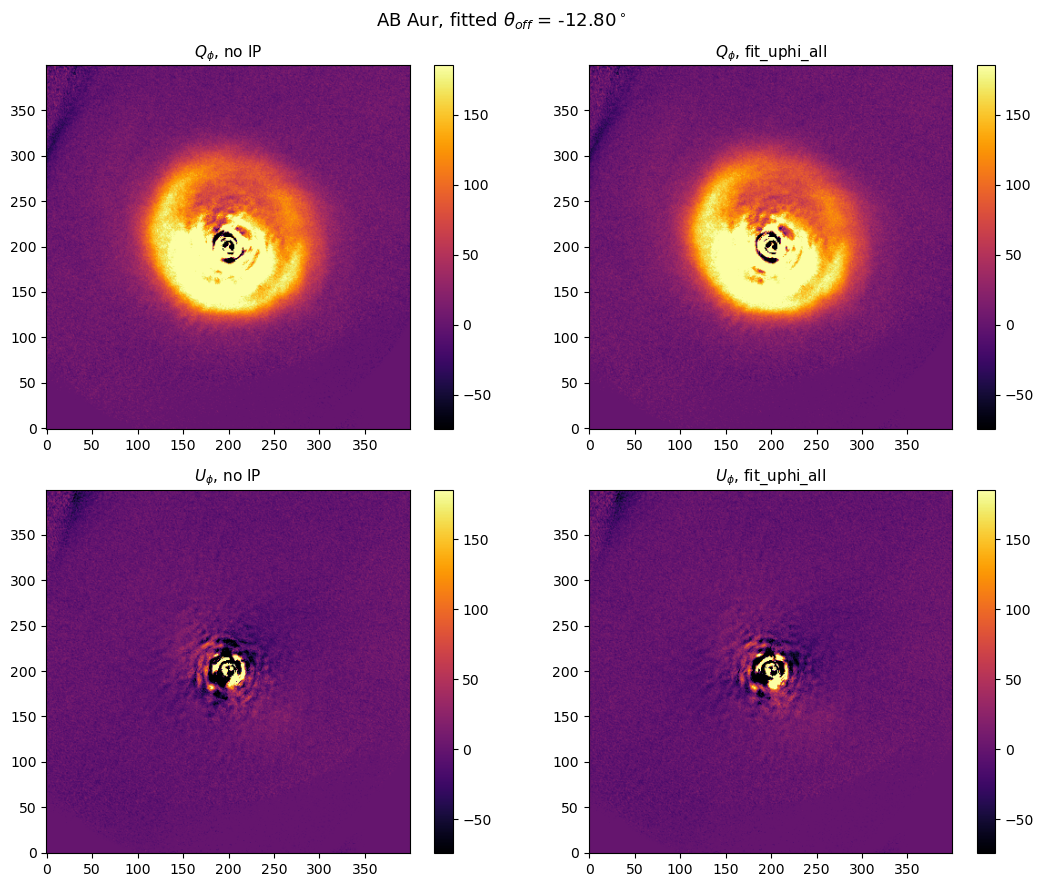

In [11]:
v = np.nanstd(b) / abs(scale)
fig, ax = plt.subplots(2, 2, figsize=(11, 9))
for a_, img, title in [(ax[0, 0], qphi, "$Q_\\phi$, no IP"),
                       (ax[0, 1], qphi_a, "$Q_\\phi$, fit_uphi_all"),
                       (ax[1, 0], uphi, "$U_\\phi$, no IP"),
                       (ax[1, 1], uphi_a, "$U_\\phi$, fit_uphi_all")]:
    im = a_.imshow(img, origin="lower", vmin=-v, vmax=2.5 * v, cmap="inferno")
    a_.set_title(title, fontsize=11)
    fig.colorbar(im, ax=a_, fraction=0.046)
fig.suptitle(f"AB Aur, fitted $\\theta_{{off}}$ = {theta_off:.2f}$^\\circ$",
             fontsize=13)
fig.tight_layout()

os.makedirs(OUT_DIR, exist_ok=True)
tag = f"fitted_theta{theta_off:.3f}"
fits.PrimaryHDU(med_all).writeto(
    os.path.join(OUT_DIR, f"median_stokes_{tag}.fits"), overwrite=True)
fig.savefig(os.path.join(OUT_DIR, f"uphi_fit_{tag}.png"), dpi=110)
print("wrote products to", OUT_DIR)